# Difference between Spey & PyHf's uncorrelated background models

Both libraries provide a "simplest possible" single-channel counting model with a per-bin background
uncertainty that is **uncorrelated between bins**. The construction at the surface looks the same, one
Poisson term per bin plus a per-bin constraint on a nuisance parameter, but the **type of constraint and
how the nuisance parameter modifies the expected yield are different**. This notebook makes the difference
explicit, both mathematically and numerically.

## 1. Mathematical construction

### 1.1 `"pyhf.uncorrelated_background"`

`pyhf` builds the model with a `shapesys` modifier (see
[uncorrelated shape section](https://pyhf.readthedocs.io/en/v0.7.6/likelihood.html#uncorrelated-shape-shapesys)). `shapesys` is a *multiplicative* modifier on the background sample,
controlled by a nuisance parameter $\gamma_i$ per bin which is constrained by a **Poisson** auxiliary
measurement.

For a relative background uncertainty $\sigma_i / n^b_i$, `pyhf` defines

$$
\alpha_i \;\equiv\; \frac{(n^b_i)^2}{\sigma_i^2}
$$

and the full likelihood is

$$
\boxed{\;
\mathcal{L}_{\text{pyhf}}(\mu, \boldsymbol{\gamma})
= \prod_{i=1}^{N} \mathrm{Poiss}\!\bigl(n^{\rm obs}_i \,\big|\, \mu n^s_i + \gamma_i n^b_i \bigr)
\;\cdot\;
\prod_{i=1}^{N} \mathrm{Poiss}\!\left(\alpha_i \,\big|\, \gamma_i\,\alpha_i\right)
\;}
$$

Key points:
* The nuisance parameter $\gamma_i$ is a **multiplicative scale factor** on the nominal background, with $\gamma_i = 1$ at the SM point.
* The constraint is **Poisson** with auxiliary observation $\alpha_i = (n^b_i/\sigma_i)^2$ — i.e. the background uncertainty is treated as if it came from a control sample of effective size $\alpha_i$.
* Bounds are $\gamma_i \in [10^{-10}, 10]$, so $\gamma_i \ge 0$ is enforced *by construction*.

### 1.2 `"default.uncorrelated_background"`

From [the plug-ins section of the documentation](https://spey.readthedocs.io/en/stable/plugins.html#default-uncorrelated-background) the model is

$$
\boxed{\;
\mathcal{L}_{\text{spey}}(\mu, \boldsymbol{\theta})
= \prod_{i=1}^{N} \mathrm{Poiss}\!\bigl(n^{\rm obs}_i \,\big|\, \mu n^s_i + n^b_i + \theta_i \sigma_i \bigr)
\;\cdot\;
\prod_{i=1}^{N} \mathcal{N}(\theta_i \mid 0, 1)
\;}
$$

Key points:
* The nuisance parameter $\theta_i$ is an **additive pull** in units of standard deviations: $n^b_i \to n^b_i + \theta_i \sigma_i$.
* The constraint is a **standard normal** centred at zero.
* Positivity of $n^b_i + \theta_i \sigma_i$ is **not implicit**; it is enforced explicitly during the fit via a `scipy.optimize.NonlinearConstraint`.

### 1.3 Reparametrisation: the two models are *not* identical

Set $\gamma_i = 1 + \theta_i \sigma_i / n^b_i$, then the Poisson mean in the main term becomes

$$
\gamma_i n^b_i = n^b_i + \theta_i \sigma_i
$$

so the main models agree exactly. The constraint terms, however, differ:

| Library | Constraint on $\gamma_i \equiv 1 + \theta_i \sigma_i / n^b_i$ |
|---|---|
| pyhf | $\mathrm{Poiss}\!\bigl(\alpha_i \mid \gamma_i \alpha_i\bigr)$ with $\alpha_i = (n^b_i/\sigma_i)^2$ |
| spey | $\mathcal{N}\!\bigl(\theta_i \mid 0, 1\bigr) = \mathcal{N}\!\bigl(\gamma_i \mid 1, \sigma_i/n^b_i\bigr)$ |

By Stirling, $\mathrm{Poiss}(\alpha \mid \gamma\alpha)$ around $\gamma = 1$ behaves like
$\mathcal{N}(\gamma \mid 1, 1/\sqrt{\alpha}) = \mathcal{N}(\gamma \mid 1, \sigma/n^b)$. So **in the
large-$\alpha$ (small relative uncertainty) limit the two constructions coincide**. They diverge when
$\sigma_i / n^b_i$ is sizeable: the Poisson constraint is asymmetric in $\gamma$ (heavier tail towards
large $\gamma$, hard floor at $\gamma=0$), while the Gaussian constraint is symmetric in $\theta$ and
assigns prior weight to $n^b + \theta\sigma < 0$ which `spey` then forbids with a hard positivity wall.

## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
import spey

print("spey :", spey.version())

Spey - WARNING: An unstable version of Spey (0.2.7-b2) is being used. Latest stable version is 0.2.6.
spey : 0.2.7-b2


## 3. A toy single-bin scenario

Single bin with $n^s = 5$, $n^b = 10$, $\sigma = 4$, $n^{\rm obs} = 11$. With $\sigma/n^b = 40\%$ the
relative uncertainty is large enough to see the Poisson/Gaussian mismatch.

In [2]:
signal = [5.0]
background = [10.0]
bkg_unc = [4.0]
data = [11]

pyhf_wrapper = spey.get_backend("pyhf.uncorrelated_background")
pyhf_model = pyhf_wrapper(
    signal_yields=signal,
    background_yields=background,
    data=data,
    absolute_uncertainties=bkg_unc,
)

print("pyhf parameters :", pyhf_model.config().parameter_names)
print(
    "pyhf auxdata    :",
    pyhf_model.backend.model()[-1][1],
    "= (n^b/sigma)^2 =",
    (background[0] / bkg_unc[0]) ** 2,
)
print("pyhf full data  :", pyhf_model.backend.model()[-1])

spey_wrapper = spey.get_backend("default.uncorrelated_background")
spey_model = spey_wrapper(
    signal_yields=signal,
    background_yields=background,
    data=data,
    absolute_uncertainties=bkg_unc,
)
print("spey backend    :", spey_model.backend.name)

pyhf parameters : ['mu', 'uncorr_bkguncrt[0]']
pyhf auxdata    : 6.25 = (n^b/sigma)^2 = 6.25
pyhf full data  : [11, 6.25]
spey backend    : default.uncorrelated_background


## 4. Compare the constraint terms directly

Plot $\ln \mathcal{C}_{\text{pyhf}}(\gamma)$ vs $\ln \mathcal{C}_{\text{spey}}(\gamma)$ as a function of the
*same* multiplicative scale $\gamma = 1 + \theta\sigma/n^b$.

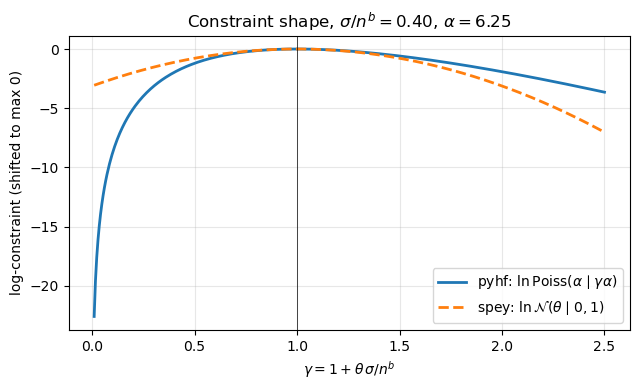

Asymmetry of the pyhf Poisson constraint vs symmetric spey Gaussian:
  pyhf  log C at gamma=0.5 : -1.207
  pyhf  log C at gamma=1.5 : -0.591
  spey  log C at theta=-1  : -0.500
  spey  log C at theta=+1  : -0.500


In [3]:
from scipy.special import gammaln, xlogy


def poisson_logpmf_continuous(k, lam):
    """Continuous Poisson log-pmf, valid for non-integer k (which pyhf needs because alpha = (n^b/sigma)^2 is generally not an integer)."""
    return xlogy(k, lam) - lam - gammaln(k + 1.0)


nb, sb = background[0], bkg_unc[0]
alpha = (nb / sb) ** 2  # pyhf auxdata
rel = sb / nb  # = 1 / sqrt(alpha)

gamma = np.linspace(0.01, 2.5, 400)
theta = (gamma - 1.0) / rel

logC_pyhf = poisson_logpmf_continuous(alpha, gamma * alpha)
logC_spey = norm.logpdf(theta, loc=0.0, scale=1.0)

logC_pyhf -= logC_pyhf.max()
logC_spey -= logC_spey.max()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(
    gamma, logC_pyhf, label=r"pyhf: $\ln\mathrm{Poiss}(\alpha\mid\gamma\alpha)$", lw=2
)
ax.plot(gamma, logC_spey, label=r"spey: $\ln\mathcal{N}(\theta\mid 0,1)$", lw=2, ls="--")
ax.axvline(1.0, color="k", lw=0.5)
ax.set_xlabel(r"$\gamma = 1 + \theta\,\sigma/n^b$")
ax.set_ylabel("log-constraint (shifted to max 0)")
ax.set_title(rf"Constraint shape, $\sigma/n^b = {rel:.2f}$, $\alpha = {alpha:.2f}$")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ref = poisson_logpmf_continuous(alpha, alpha)
print("Asymmetry of the pyhf Poisson constraint vs symmetric spey Gaussian:")
print(
    f"  pyhf  log C at gamma=0.5 : {poisson_logpmf_continuous(alpha, 0.5*alpha) - ref:+.3f}"
)
print(
    f"  pyhf  log C at gamma=1.5 : {poisson_logpmf_continuous(alpha, 1.5*alpha) - ref:+.3f}"
)
print(f"  spey  log C at theta=-1  : {norm.logpdf(-1.0) - norm.logpdf(0.0):+.3f}")
print(f"  spey  log C at theta=+1  : {norm.logpdf(+1.0) - norm.logpdf(0.0):+.3f}")

The spey Gaussian is symmetric in $\theta$, while the pyhf Poisson is **skewed**: it penalises downward
fluctuations of the background more than upward ones. At small relative uncertainty the two curves
overlap; at 40% they visibly disagree.

## 5. Profile likelihood ratio

Profile out the nuisance parameter and compare $-2 \ln \Lambda(\mu)$.

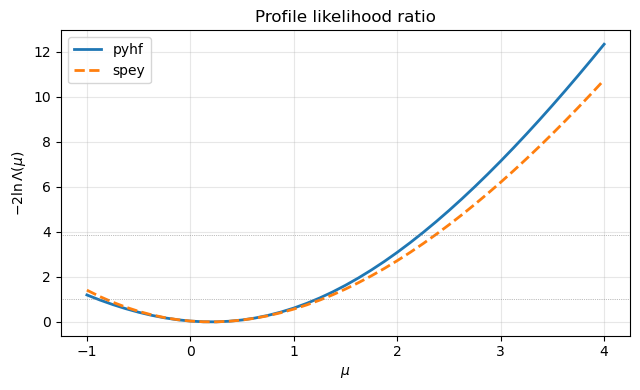

In [4]:
mu_grid = np.linspace(-1.0, 4.0, 41)

pyhf_nlls = np.array([pyhf_model.likelihood(poi_test=float(m)) for m in mu_grid])
spey_nlls = np.array([spey_model.likelihood(poi_test=float(m)) for m in mu_grid])

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(mu_grid, 2 * (pyhf_nlls - pyhf_nlls.min()), label="pyhf", lw=2)
ax.plot(mu_grid, 2 * (spey_nlls - spey_nlls.min()), label="spey", lw=2, ls="--")
ax.axhline(1.0, color="grey", lw=0.5, ls=":")
ax.axhline(3.84, color="grey", lw=0.5, ls=":")
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$-2\ln\Lambda(\mu)$")
ax.set_title("Profile likelihood ratio")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. $CL_s$ exclusion at $ \mu = 1$

In [5]:
excl_pyhf = float(pyhf_model.exclusion_confidence_level(poi_test=1.0)[0])
excl_spey = float(spey_model.exclusion_confidence_level(poi_test=1.0)[0])

print(f"pyhf  exclusion conf.    : {excl_pyhf:.4f}")
print(f"spey  exclusion conf.    : {excl_spey:.4f}")
print(f"difference (spey - pyhf) : {excl_spey - excl_pyhf:+.4f}")

pyhf  exclusion conf.    : 0.6235
spey  exclusion conf.    : 0.5759
difference (spey - pyhf) : -0.0476


## 7. Scaling: how the difference depends on $\sigma / n^b$

Sweep the relative uncertainty. Small $\sigma/n^b$: the two libraries should agree (Gaussian limit of
Poisson). Large $\sigma/n^b$: they should split.

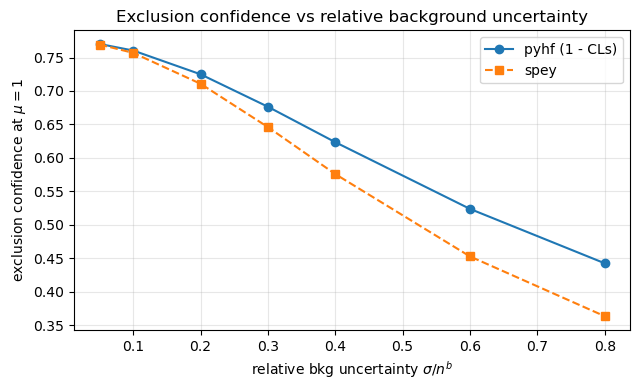

,sigma/n_b,exclusion (pyhf),exclusion (spey)
0,0.05,0.7703,0.7694
1,0.10,0.7604,0.7569
2,0.20,0.7249,0.7108
3,0.30,0.6764,0.6461
4,0.40,0.6235,0.5759
5,0.60,0.5239,0.4529
6,0.80,0.4427,0.3636


In [7]:
rel_uncs = np.array([0.05, 0.10, 0.20, 0.30, 0.40, 0.60, 0.80])
results = []

for r in rel_uncs:
    sb_i = r * nb

    pm = pyhf_wrapper(
        signal_yields=signal,
        background_yields=background,
        data=data,
        absolute_uncertainties=[sb_i],
    )

    excl_p = float(pm.exclusion_confidence_level(poi_test=1.0)[0])

    sm = spey_wrapper(
        signal_yields=signal,
        background_yields=background,
        data=data,
        absolute_uncertainties=[sb_i],
    )
    excl_s = float(sm.exclusion_confidence_level(poi_test=1.0)[0])
    results.append((r, excl_p, excl_s))

results = np.array(results)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(results[:, 0], results[:, 1], "o-", label="pyhf (1 - CLs)")
ax.plot(results[:, 0], results[:, 2], "s--", label="spey")
ax.set_xlabel(r"relative bkg uncertainty $\sigma/n^b$")
ax.set_ylabel(r"exclusion confidence at $\mu = 1$")
ax.set_title("Exclusion confidence vs relative background uncertainty")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pd.DataFrame(
    results, columns=["sigma/n_b", "exclusion (pyhf)", "exclusion (spey)"]
).round(4)

## 8. Summary

| Aspect | `pyhf` `uncorrelated_background` | `spey` `default.uncorrelated_background` |
|---|---|---|
| Modifier type | `shapesys` (multiplicative) | additive `theta * sigma` |
| Nuisance parameter | $\gamma_i$, nominal $\gamma_i = 1$ | $\theta_i$, nominal $\theta_i = 0$ |
| Effect on yield | $\lambda_i = \mu n^s_i + \gamma_i n^b_i$ | $\lambda_i = \mu n^s_i + n^b_i + \theta_i \sigma_i$ |
| Constraint | Poisson with auxdata $\alpha_i = (n^b_i/\sigma_i)^2$ | Standard normal $\mathcal{N}(0,1)$ |
| Positivity of $n^b$ | guaranteed by $\gamma_i \in [10^{-10}, 10]$ | enforced via `NonlinearConstraint` during fit |
| Symmetry of constraint | **asymmetric** in $\gamma$ | symmetric in $\theta$ |
| $\sigma/n^b \ll 1$ | Stirling limit $\to$ Gaussian | identical to pyhf |
| $\sigma/n^b \gtrsim 0.3$ | skewed, harder downward penalty | symmetric pull |

**Bottom line.** Under the reparametrisation $\gamma_i = 1 + \theta_i\sigma_i/n^b_i$ the *main Poisson term*
is identical in the two libraries. The difference is entirely in the **constraint**: pyhf uses an
asymmetric Poisson constraint on the multiplicative scale, while spey's `default.uncorrelated_background`
uses a strictly Gaussian constraint on an additive pull. The discrepancy is invisible for small relative
background uncertainties (small $\sigma/n^b$, Stirling limit) and grows once $\sigma/n^b$ exceeds
$\sim 30\%$, where the Poisson skewness becomes a real effect, visible above as the splitting of the two
exclusion-confidence curves.

Use `pyhf` (or the `spey-pyhf` plugin that wraps it) when you need a Poisson-constrained uncorrelated
background; use `spey`'s `default.uncorrelated_background` when you only have an absolute per-bin Gaussian
uncertainty (typical for simplified likelihoods, [arXiv:1809.05548](https://arxiv.org/abs/1809.05548))).

The reason for the differenfe is because in the `HistFactory` formalism that `pyhf` implements, shapesys is meant to model a statistical uncertainty on the background prediction and statistical uncertainties are Poisson by construction, not Gaussian.

The deeper reasoning has several threads:

1. The number $\alpha_i = (n^b_i/\sigma_i)^2$ has a physical meaning.
It is the effective sample size of the (real or MC) control region that produced the background prediction. If you imagine a control sample of $\alpha_i$ events, scaled by a factor $n^b_i / \alpha_i$ to produce the prediction $n^b_i$, then the statistical uncertainty of that prediction is exactly $\sqrt{\alpha_i} \cdot \frac{n^b_i}{\alpha_i} = \frac{n^b_i}{\sqrt{\alpha_i}} = \sigma_i.$
So `shapesys` is literally saying "the background in bin i was estimated from $\alpha_i$ effective events", and the auxiliary measurement is the Poisson count of those events. A Gaussian constraint would discard this interpretation.

2. Positivity is enforced for free.
A Poisson constraint hard-zeros at $\gamma_i = 0$. The expected background $\gamma_i n^b_i$ literally cannot go negative. A Gaussian on $\theta_i$ has nonzero prior mass at $n^b_i + \theta_i \sigma_i < 0$, which is unphysical and is why spey has to bolt on an explicit `NonlinearConstraint` during optimisation. For low-statistics bins where $\sigma_i / n^b_i$ is large, this matters numerically (it's where the two constructions visibly disagree, as the notebook shows).

3. It's the Barlow–Beeston-lite construction.
`shapesys` is the same recipe Barlow & Beeston used for MC statistical uncertainties: one Poisson-constrained nuisance per bin, with the effective count interpreted as a control measurement. So this is consistent with how MC stats are treated everywhere else in HistFactory (`staterror`).

4. HistFactory has a clear convention.
Stat-like uncertainties (`shapesys`, `staterror`) → Poisson constraint; systematic-like uncertainties (`normsys`, `histosys`) → Gaussian constraint. `pyhf.uncorrelated_background` chose `shapesys` because the natural interpretation of a per-bin background uncertainty with no further context is "stat error on the prediction".

5. The Stirling limit gives you the Gaussian back when it's appropriate.
For high-stats bins ($\alpha_i \gg 1$, equivalently $\sigma_i / n^b_i \ll 1$), Stirling turns the Poisson into a Gaussian with width $\sigma_i$, so you lose nothing in the regime where Gaussian is a good description, and you keep the correct asymmetric tail in the regime where it isn't.

So the difference is really a difference in intent: `pyhf` models a statistical control measurement; `spey`'s `default.uncorrelated_background` models a generic absolute Gaussian uncertainty (as in the simplified-likelihood prescription, [arXiv:1809.05548](https://arxiv.org/abs/1809.05548)).
